# Exercise 0.3: Numerical linear algebra methods

---

In this exercise, you will get familiar with `numpy.array` and `numpy.linalg`.

Consider the Heisenberg model of **two** spins,

\begin{equation*}
    \hat{H} = \sum_{\alpha=x,y,z} \hat{\sigma}_1^\alpha \hat{\sigma}_2^\alpha = \hat{\sigma}_1^x \otimes \hat{\sigma}_2^x + \hat{\sigma}_1^y \otimes \hat{\sigma}_2^y + \hat{\sigma}_1^z \otimes \hat{\sigma}_2^z\,,
\end{equation*}

where the Pauli matrices are given as 

\begin{align*}
    \hat{\sigma}^x = \begin{pmatrix}
    0 & 1\\
    1 & 0
    \end{pmatrix}, \qquad
    \hat{\sigma}^y = \begin{pmatrix}
    0 & -i\\
    i & 0
    \end{pmatrix}, \qquad
    \hat{\sigma}^z = \begin{pmatrix}
    1 & 0\\
    0 & -1
    \end{pmatrix}.
\end{align*}

---

In [1]:
### Necessary Python libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
### If you wish, you can import more libraries here

---

## Exercise 0.3-a

Construct the Pauli matrices as numpy arrays `sigma_x`, `sigma_y`, and `sigma_z`.

In [3]:
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1.j], [1.j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

In [4]:
# 0.2-a tests
assert type(sigma_x) is np.ndarray, "sigma_x must be a numpy array."
assert type(sigma_y) is np.ndarray, "sigma_y must be a numpy array."
assert type(sigma_z) is np.ndarray, "sigma_z must be a numpy array."
assert sigma_x.shape == (2, 2), "sigma_x must be of shape (2, 2)."
assert sigma_y.shape == (2, 2), "sigma_y must be of shape (2, 2)."
assert sigma_z.shape == (2, 2), "sigma_z must be of shape (2, 2)."

---

## Exercise 0.3-b

Construct the Hamiltonian of the Heisenberg model as a numpy array `H`.

> **Hint:** For the *kronecker product* $A\otimes B$ you may use `np.kron(A, B)`

In [5]:
H = np.kron(sigma_x, sigma_x) + np.kron(sigma_y, sigma_y) + np.kron(sigma_z, sigma_z)
print(H)

[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


In [6]:
# 0.3-b tests
assert type(H) is np.ndarray, "H must be a numpy array."
assert H.shape == (4, 4), "H must be of shape (4, 4)."
# check some of the entries of H
assert np.isclose(H[0, 0], 1).item()
assert np.isclose(H[2, 1], 2).item()
assert np.isclose(H[2, 2], -1).item()
assert np.isclose(H[3, 1], 0).item()

---

## Exercise 0.3-c

Diagonalize the Hamiltonian. What are the eigenvalues and eigenstates?

> **Hint:** You can use `numpy.linalg.eigh` to obtain eigenvalues and eigenvectors of hermitean matrices.

In [7]:
eiengvalues, eigenvectors = np.linalg.eigh(H)
# The eigenvectors are stored in the columns of the returned array!
for i in range(eiengvalues.size):
    print(f"eigenvalue = {eiengvalues[i]}, eigenvector = {np.round(np.real_if_close(eigenvectors[:, i]), 3)}")

eigenvalue = -3.0, eigenvector = [ 0.     0.707 -0.707  0.   ]
eigenvalue = 1.0, eigenvector = [1. 0. 0. 0.]
eigenvalue = 1.0, eigenvector = [0.    0.707 0.707 0.   ]
eigenvalue = 1.0, eigenvector = [0. 0. 0. 1.]


In [8]:
# 0.3-c tests
assert eiengvalues.size == 4
assert eigenvectors.shape == (4, 4)

The basis of one spin-$\frac{1}{2}$ is $\{\ket{\uparrow}, \ket{\downarrow}\}$, and the basis of a system of two spins is $\{\ket{\uparrow\uparrow}, \ket{\uparrow\downarrow}, \ket{\downarrow\uparrow}, \ket{\downarrow\downarrow}\}$.

The ground state has energy $E=-3$ and is given by

\begin{equation*}
    \frac{1}{\sqrt{2}}\left(\ket{\uparrow\downarrow}-\ket{\downarrow\uparrow}\right)
\end{equation*}

(singlet state).

The three excited states are degenerate with energy $E=1$. The states are given by

\begin{equation*}
    \ket{\uparrow\uparrow},
\end{equation*}

\begin{equation*}
    \frac{1}{\sqrt{2}}\left(\ket{\uparrow\downarrow}+\ket{\downarrow\uparrow}\right),
\end{equation*}

\begin{equation*}
    \ket{\downarrow\downarrow}
\end{equation*}

(Excited degenerate triplet state).

---

## Exercise 0.3-d

Construct the operator for the total magnetization in $z$ direction,

\begin{equation*}
    M = \sigma_1^z \otimes \mathbb{1}_2  +\mathbb{1}_1 \otimes \sigma_2^z \,,
\end{equation*}

and compute its expectation value and variance $\langle M^2\rangle-\langle M \rangle^2$ for for the ground state of $H$ as well as for the state $\frac{1}{\sqrt{2}}(\ket{\uparrow \uparrow}+\ket{\downarrow \downarrow})$.

In [9]:
# Construct operator
eye = np.eye(2) # 2x2 identity matrix
M = np.kron(sigma_z, eye) + np.kron(eye, sigma_z)

# Construct special state
special_state = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

# Compute expectation values and variance
print("ground state:")
M_exp_ground_state = eigenvectors[:, 0].conj().T @ M @ eigenvectors[:, 0]
M_variance_ground_state = eigenvectors[:, 0].conj().T @ M @ M @ eigenvectors[:, 0] - M_exp_ground_state**2
print(f"<M> = {M_exp_ground_state}, <M^2>->M>^2 = {M_variance_ground_state}")
print("special state:")
M_exp_special_state = special_state.conj().T @ M @ special_state
M_variance_special_state = special_state.conj().T @ M @ M @ special_state - M_exp_ground_state**2
print(f"<M> = {M_exp_special_state}, <M^2>->M>^2 = {M_variance_special_state}")

ground state:
<M> = 0j, <M^2>->M>^2 = 0j
special state:
<M> = 0.0, <M^2>->M>^2 = (3.999999999999999+0j)


---

## Exercise 0.3-e (optional)

How would you generalize your code from part (b)-(d) to more than two spins with the same nearest-neighbor Heisenberg interaction?

In [10]:
def construct_NN_interaction_operator(operator, L, pbc=False):
    """
    Construct a nearest-neighbor interaction operator for a 1D lattice, made up of terms where the given single-site
    operator is applied at the two sites of a NN bond.

    Parameters
    ----------
    operator : np.ndarray
        Local operator to apply on each site. The function expects a dxd square matrix,
        where d is the dimension of the local Hilbert space
    L : int
        Length of the chain.
    pbc : bool, optional
        Whether to use periodic boundary conditions. Default: False.

    Returns
    -------
    np.ndarray
        The full many-body operator as a matrix of dimension (d^L, d^L)
    """
    terms = []
    for bond in range(L-1):
        term = eye
        if bond == 0 or (pbc == True and bond == L-1):
            term = operator
        for j in range(1, L):
            if j == bond or j == bond+1:
                term = np.kron(term, operator)
            else:
                term = np.kron(term, eye)
        terms.append(term)
    return sum(terms)
    
def create_M_operator(L):
    """
    Constructs the magnetization operator for a 1D spin-1/2 chain of length L
    """
    terms = []
    for i in range(L):
        term = eye
        if i == 0:
            term = sigma_z
        for j in range(1, L):
            if i == j:
                term = np.kron(term, sigma_z)
            else:
                term = np.kron(term, eye)
        terms.append(term)
    return sum(terms)

L = 3
H = construct_NN_interaction_operator(sigma_x, L, pbc=False) + construct_NN_interaction_operator(sigma_y, L, pbc=False) + construct_NN_interaction_operator(sigma_z, L, pbc=False)
print("Open boundary conditions:")
print(H)
print("Periodic boundary conditions:")
H = construct_NN_interaction_operator(sigma_x, L, pbc=True) + construct_NN_interaction_operator(sigma_y, L, pbc=True) + construct_NN_interaction_operator(sigma_z, L, pbc=True)
print(H)

Open boundary conditions:
[[ 2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j -2.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j -2.+0.j  2.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  2.+0.j]]
Periodic boundary conditions:
[[ 2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j -2.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  2.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  2.+0.j  0.+0.j -2.+0.j  2.+0.j  0.+0.j]
 [ 0.

In [11]:
def solve_heisenberg_model(L, pbc=False):
    # Construct Hamiltonian
    H = construct_NN_interaction_operator(sigma_x, L, pbc=pbc) + construct_NN_interaction_operator(sigma_y, L, pbc=pbc) + construct_NN_interaction_operator(sigma_z, L, pbc=pbc)
    # Solve for eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    return eigenvalues, eigenvectors

groundstate_energies = []
groundstate_degeneracies = []
M_exps = []
M_variances = []
psis = []
Ls = list(range(2, 10))
pbc = True

for L in Ls:
    eigenvalues, eigenvectors = solve_heisenberg_model(L, pbc=pbc)
    groundstate_energies.append(eigenvalues[0])
    # Compute ground state degeneracy
    groundstate_degeneracy = np.count_nonzero(np.isclose(eigenvalues, eigenvalues[0]))
    groundstate_degeneracies.append(groundstate_degeneracy)
    # Compute magnetization and variance
    M = create_M_operator(L)
    M_exp = [eigenvectors[:, n].conj().T @ M @ eigenvectors[:, n] for n in range(groundstate_degeneracy)]
    M_variance = [eigenvectors[:, n].conj().T @ M @ M @ eigenvectors[:, n] - M_exp[n]**2 for n in range(groundstate_degeneracy)]
    M_exps.append(M_exp)
    M_variances.append(M_variance)
    psis.append([eigenvectors[:, n] for n in range(groundstate_degeneracy)])

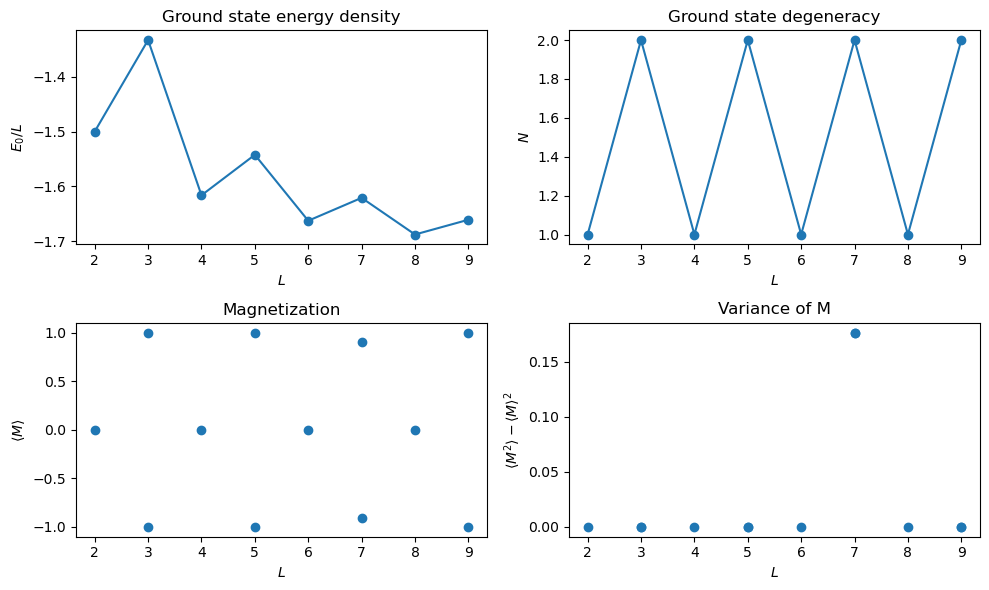

In [12]:
fig, axarray = plt.subplots(2, 2, figsize=(10, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Plot gs energy
axarray[0, 0].plot(Ls, np.array(groundstate_energies)/np.array(Ls), "o-")
axarray[0, 0].set_title("Ground state energy density")
axarray[0, 0].set_ylabel(r"$E_0/L$")
axarray[0, 0].set_xlabel(r"$L$")

# Plot gs degeneracy
axarray[0, 1].plot(Ls, groundstate_degeneracies, "o-")
axarray[0, 1].set_title("Ground state degeneracy")
axarray[0, 1].set_ylabel(r"$N$")
axarray[0, 1].set_xlabel(r"$L$")

# Plot gs magnetization
for i, M_exp in enumerate(M_exps):
    axarray[1, 0].plot([Ls[i]]*groundstate_degeneracies[i], np.real_if_close(M_exp), "o", color=colors[0])
axarray[1, 0].set_title("Magnetization")
axarray[1, 0].set_ylabel(r"$\langle M\rangle$")
axarray[1, 0].set_xlabel(r"$L$")

# Plot gs magnetization variance
for i, M_variance in enumerate(M_variances):
    plt.plot([Ls[i]]*groundstate_degeneracies[i], np.real_if_close(M_variance), "o", color=colors[0])
axarray[1, 1].set_title("Variance of M")
axarray[1, 1].set_ylabel(r"$\langle M^2\rangle - \langle M\rangle^2$")
axarray[1, 1].set_xlabel(r"$L$")

plt.tight_layout()
plt.show()